# Star Tracker & Earth Limb Day/Night Constraints Demo

This notebook demonstrates how to use `pandoravisibility` with:
- **Day/night Earth limb constraints** — stricter keep-out when the nearest limb is sunlit
- **Star tracker keep-out constraints** — Sun and Earth limb avoidance for star trackers
- **Orbit-optimal roll** — automatic roll selection to maximise star tracker compliance
- **Human-readable summaries** — per-timestep constraint reports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.visualization import time_support

from pandoravisibility import Visibility

## 1. Define the TLE

Use Pandora's draft TLE (update to the latest available for real work).

In [2]:
line1 = "1 67395U 80229J   26057.99991898  .00000000  00000-0  37770-3 0    03"
line2 = "2 67395  97.8009  58.3973 0006599 121.8878 132.9207 14.87804761    04"

## 2. Create a Visibility instance with day/night & star tracker constraints

Key parameters:
| Parameter | Meaning |
|---|---|
| `earthlimb_day_min` | Minimum separation from the Earth limb when the limb is **sunlit** (day) |
| `earthlimb_night_min` | Minimum separation from the Earth limb when the limb is **dark** (night) |
| `st_sun_min` | Star tracker Sun keep-out angle |
| `st_earthlimb_min` | Star tracker Earth-limb keep-out angle |
| `st_required` | Number of star trackers that must pass (1 or 2) |

In [3]:
vis = Visibility(
    line1, line2,
    # Day/night Earth limb thresholds
    earthlimb_day_min=45 * u.deg,    # stricter during daylit limb
    earthlimb_night_min=15 * u.deg,   # relaxed during dark limb
    # Star tracker keep-outs
    st_sun_min=44 * u.deg,
    st_earthlimb_min=30 * u.deg,
    st_required=1,                   # at least 1 tracker must be clear
)

print(vis)

<Visibility: SAT67395 [moon≥25 deg, sun≥91 deg, limb_day≥45 deg, limb_night≥15 deg, st_sun≥44 deg, st_limb≥30 deg, st_req=1]>


## 3. Choose a target and build a time grid

We pick GJ 1214 and sample 3 orbital periods at 1-minute cadence so we can
see the day/night limb transitions and star tracker behaviour within each orbit.

In [4]:
target = SkyCoord(258.831, 4.96068, frame="icrs", unit="deg")

t0 = Time("2026-05-05T00:00:00")
period = vis.get_period()
print(f"Orbital period: {period:.2f}")

# 3 orbits at 1-minute cadence
n_minutes = int(3 * period.to(u.min).value)
times = t0 + TimeDelta(np.arange(n_minutes) * u.min)
print(f"Time grid: {len(times)} steps from {times[0].iso} to {times[-1].iso}")

Orbital period: 96.79 min
Time grid: 290 steps from 2026-05-05 00:00:00.000 to 2026-05-05 04:49:00.000


## 4. Basic visibility (boresight only, no roll optimisation)

`get_visibility()` returns a boolean array telling you whether the target
passes **all** constraints at each time step.

In [5]:
basic_vis = vis.get_visibility(target, times)

print(f"Visible at {basic_vis.sum()} of {len(times)} time steps "
      f"({100 * basic_vis.mean():.1f}% duty cycle)")

Visible at 69 of 290 time steps (23.8% duty cycle)


## 5. Orbit-optimal roll visibility

`get_visibility_best_roll()` sweeps roll angles for each orbit and picks
the one that maximises the number of boresight-visible time steps with
valid star tracker geometry. It returns a dict with:

| Key | Description |
|---|---|
| `visible` | Full visibility (boresight + star trackers at optimal roll) |
| `boresight_visible` | Boresight-only visibility (ignoring star trackers) |
| `roll_deg` | Chosen roll angle per time step (constant within each orbit) |
| `n_st_pass` | Number of star trackers passing at the chosen roll (0–2) |
| `solar_power_frac` | Solar panel power fraction at the chosen roll |

In [6]:
res = vis.get_visibility_best_roll(
    target, times,
    roll_step=5 * u.deg,
    orbit_time_step=1 * u.min,
)

print("Visibility summary (best-roll):")
print(f"  Total time steps:         {len(times)}")
print(f"  Boresight visible:        {int(np.sum(res['boresight_visible']))}")
print(f"  Fully visible (incl. ST): {int(np.sum(res['visible']))}")
print(f"  Median roll used:         {np.nanmedian(res['roll_deg']):.1f} deg")
print(f"  Median ST passing:        {np.nanmedian(res['n_st_pass']):.1f}")

Visibility summary (best-roll):
  Total time steps:         290
  Boresight visible:        145
  Fully visible (incl. ST): 145
  Median roll used:         -65.0 deg
  Median ST passing:        0.5


## 6. Human-readable summary at representative times

`summary()` prints a per-constraint report for a single time step,
including which Earth limb regime (day/night) is active and the
pass/fail status of each star tracker.

In [7]:
# Show summaries at three representative times: start, middle, end
for idx in [0, len(times) // 2, -1]:
    print(f"\n{'='*60}")
    print(f"Time step index: {idx}")
    print(vis.summary(target, times[idx]))


Time step index: 0
Visibility Summary
Target: 17h15m19.4s +04d57m38.4s
Time:   2026-05-05 00:00:00.000
Sat:    67395
Moon       ✓ PASS (req:   25.0 deg, actual:   33.0 deg)
Sun        ✓ PASS (req:   91.0 deg, actual:  137.7 deg)
Earthlimb  ✗ FAIL (req:   15.0 deg [night], actual:  -14.2 deg)
------------------------------------------------------------
Star Tracker Constraints (need ≥1 tracker passing):
  ST1       ✓ PASS
    sun:✓ req:  44.0 deg act: 108.4 deg
    limb:✓ req:  30.0 deg act:  77.3 deg
  ST2       ✗ FAIL
    sun:✓ req:  44.0 deg act: 108.4 deg
    limb:✗ req:  30.0 deg act:   8.6 deg
  Result   ✓ PASS
Overall: ✗ NOT VISIBLE

Time step index: 145
Visibility Summary
Target: 17h15m19.4s +04d57m38.4s
Time:   2026-05-05 02:25:00.000
Sat:    67395
Moon       ✓ PASS (req:   25.0 deg, actual:   32.9 deg)
Sun        ✓ PASS (req:   91.0 deg, actual:  137.7 deg)
Earthlimb  ✓ PASS (req:   15.0 deg [night], actual:   62.5 deg)
--------------------------------------------------------

## 7. Visualise results

Plot boresight visibility, full visibility (with star trackers), and
star tracker pass count over the 3-orbit window.

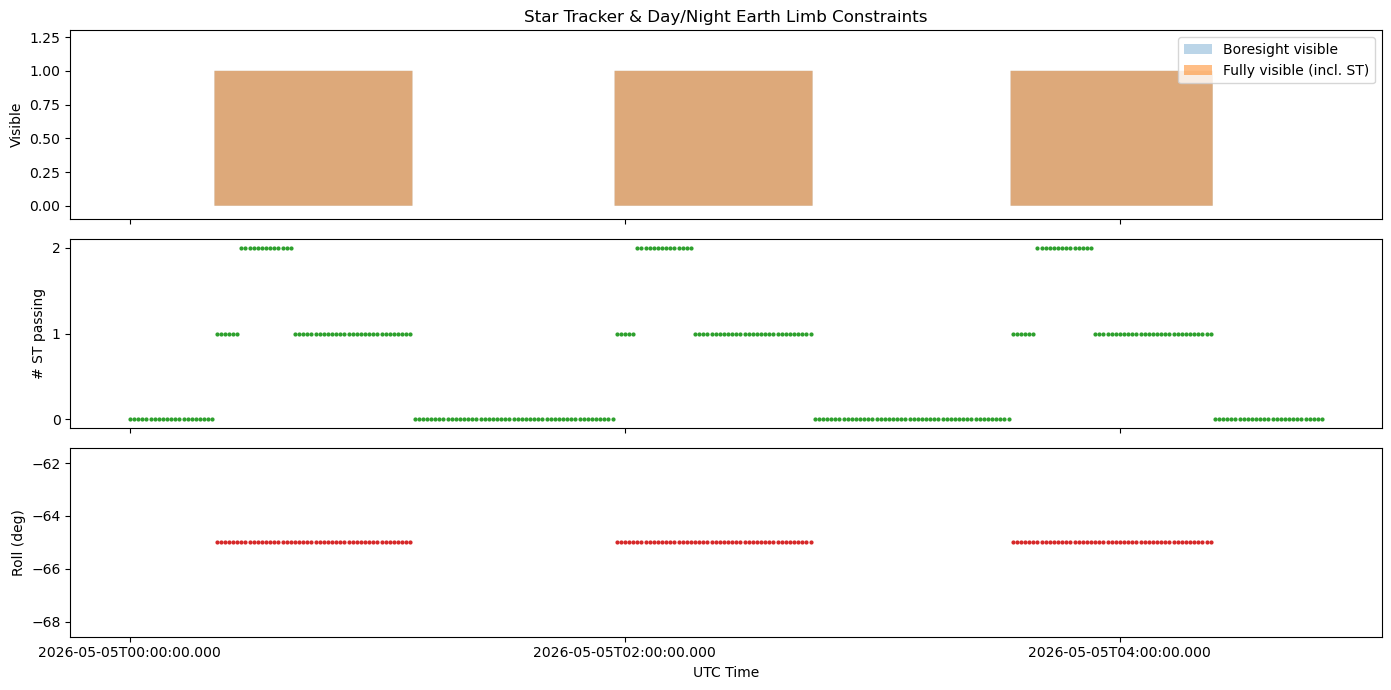

In [8]:
with time_support():
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

    # Panel 1: boresight vs full visibility
    axes[0].fill_between(times.utc, res['boresight_visible'].astype(int),
                         alpha=0.3, step='mid', label='Boresight visible')
    axes[0].fill_between(times.utc, res['visible'].astype(int),
                         alpha=0.5, step='mid', label='Fully visible (incl. ST)')
    axes[0].set_ylabel('Visible')
    axes[0].set_ylim(-0.1, 1.3)
    axes[0].legend(loc='upper right')
    axes[0].set_title('Star Tracker & Day/Night Earth Limb Constraints')

    # Panel 2: number of star trackers passing
    axes[1].scatter(times.utc, res['n_st_pass'], s=4, c='C2')
    axes[1].set_ylabel('# ST passing')
    axes[1].set_yticks([0, 1, 2])

    # Panel 3: roll angle
    axes[2].scatter(times.utc, res['roll_deg'], s=4, c='C3')
    axes[2].set_ylabel('Roll (deg)')
    axes[2].set_xlabel('UTC Time')

    plt.tight_layout()

## 8. Compare with and without day/night limb distinction

To see the effect of day/night Earth limb thresholds, compare against a
uniform limb constraint set to the daytime value.

In [9]:
vis_uniform = Visibility(
    line1, line2,
    earthlimb_min=30 * u.deg,  # same as daytime value, no day/night split
    st_sun_min=44 * u.deg,
    st_earthlimb_min=30 * u.deg,
    st_required=1,
)

res_uniform = vis_uniform.get_visibility_best_roll(
    target, times, roll_step=5 * u.deg, orbit_time_step=1 * u.min,
)

print("Day/Night split (45° day / 15° night):")
print(f"  Fully visible steps: {int(np.sum(res['visible']))} / {len(times)}")
print(f"\nUniform limb (30° always):")
print(f"  Fully visible steps: {int(np.sum(res_uniform['visible']))} / {len(times)}")
print(f"\nExtra visible steps from day/night split: "
      f"{int(np.sum(res['visible'])) - int(np.sum(res_uniform['visible']))}")

Day/Night split (45° day / 15° night):
  Fully visible steps: 145 / 290

Uniform limb (30° always):
  Fully visible steps: 132 / 290

Extra visible steps from day/night split: 13


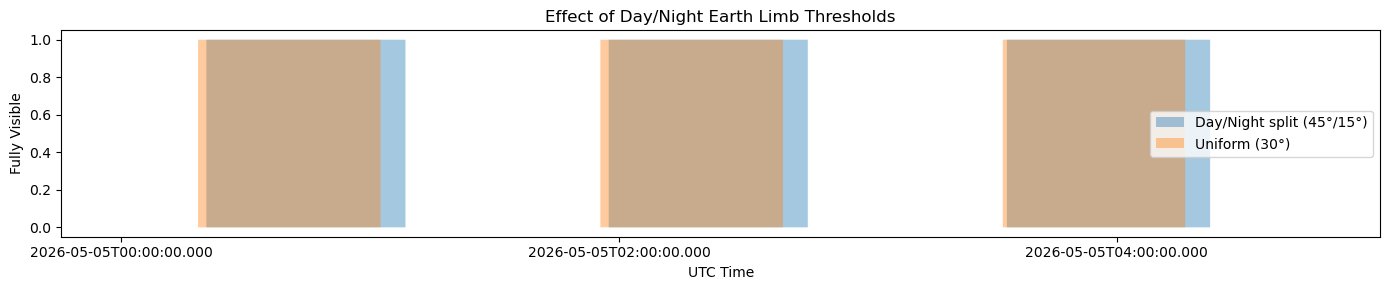

In [10]:
with time_support():
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.fill_between(times.utc, res['visible'].astype(int),
                    alpha=0.4, step='mid', label='Day/Night split (45°/15°)')
    ax.fill_between(times.utc, res_uniform['visible'].astype(int),
                    alpha=0.4, step='mid', label='Uniform (30°)')
    ax.set_ylabel('Fully Visible')
    ax.set_xlabel('UTC Time')
    ax.set_title('Effect of Day/Night Earth Limb Thresholds')
    ax.legend()
    plt.tight_layout()

## 9. Per-tracker overrides

You can also set different Earth limb keep-out angles for each star tracker
individually using `st1_earthlimb_min` and `st2_earthlimb_min`, and require
both trackers to pass with `st_required=2`.

In [11]:
vis_strict = Visibility(
    line1, line2,
    earthlimb_day_min=45 * u.deg,
    earthlimb_night_min=15 * u.deg,
    st_sun_min=44 * u.deg,
    st1_earthlimb_min=45 * u.deg,   # stricter for tracker 1
    st2_earthlimb_min=15 * u.deg,   # slightly relaxed for tracker 2
    st_required=2,                   # both trackers must pass
)

print(vis_strict)

res_strict = vis_strict.get_visibility_best_roll(
    target, times, roll_step=5 * u.deg, orbit_time_step=1 * u.min,
)

print(f"\nWith st_required=2 & per-tracker overrides:")
print(f"  Fully visible: {int(np.sum(res_strict['visible']))} / {len(times)} steps")
print(f"  vs. st_required=1:  {int(np.sum(res['visible']))} / {len(times)} steps")

<Visibility: SAT67395 [moon≥25 deg, sun≥91 deg, limb_day≥45 deg, limb_night≥15 deg, st_sun≥44 deg, st1_limb≥45 deg, st2_limb≥15 deg, st_req=2]>

With st_required=2 & per-tracker overrides:
  Fully visible: 58 / 290 steps
  vs. st_required=1:  145 / 290 steps
